# Uczenie maszynowe. Lista 3
### Wprowadzenie do klasyfikacji przez regresję

**Rys teoretyczny.** _Klasyfikacja_ to zadanie polegające na przypisaniu obiektów określonych na pewnej dziedzinie do określonych kategorii.
W kontekście uczenia maszynowego rozumiemy przez to, że proces ten przebiega w oparciu o wzorce _nauczone_ z danych uczących.
Aby matematycznie sformalizować to zadanie zakładamy, że dziedzina stanowi pewną przestrzeń wektorową, a więc obiekty - dane - można reprezentować za pomocą $d$-wymiarowego wektora ($x \in \mathbb{R}^d$).
Bez straty ogólności przyjmijmy również, że każdy obiekt może należeć tylko do jednej z $k$ kategorii jednocześnie ($y \in \{0, \cdots, k-1\}$).
Przy tych założeniach "przypisanie obiektów do kategorii" można wyrazić jako znalezienie takiej funkcji $f(x)$, która dla wszystkich danych wejściowych ($X$) "najlepiej" przewiduje ich kategorie ($\hat{Y}$).

W istocie, _znalezienie pewnej funkcji_ stanowi podstawowy problem dla bodaj całej dziedziny uczenia maszynowego;
w związku z tym odejdźmy na moment od klasyfikacji i zastanówmy się nad tym ogólnym problemem.

**Regresja.** W zadaniach klasy _uczenia nadzorowanego_ zakładamy, że dysponujemy tzw. _zbiorem uczącym_ $(x,y)$ zawierającym przykłady obiektów $x$ oraz znanych wartości odpowiadających im zmiennych zależnych $y$ (tj. _etykiet_).
W trakcie procesu uczenia przyjmujemy pewną funkcję $f$ (często zapisywaną jako $f(x,\theta)$) a następnie znajdujemy takie wartości parametrów tej funkcji ($\theta$), że zwracane przez nią wartości $\hat{y}=f(x,\theta)$ będą jak najlepiej odpowiadały etykietom $y$.
Sformułowanie "jak najlepiej" sformalizujemy przy pomocy odrębnej funkcji, zwanej _funkcją kosztu_ ($L(y,\hat{y})$, nieraz $\mathcal{L(y,\hat{y})}$).
$L(y,\hat{y})=0$ oznacza idealne dopasowanie pomiędzy predykcjami modelu $\hat{y}$ a etykietami $y$, a im większa wartość $L$ tym dopasowanie gorsze.
Znalezienie wartości wektora $\theta$ odbywa się zwykle w drodze _optymalizacji_ i zależy ściśle od doboru funkcji $f$ - na tym etapie nie będziemy podejmować tego tematu.

**Na przykład,** załóżmy zbiór o jednowymiarowej dziedzinie ($x \in \mathbb{R}^1$):
$$X=\begin{bmatrix}1.0\\2.0\\3.0\end{bmatrix}; Y=\begin{bmatrix}0\\3\\8\end{bmatrix}$$
Moglibyśmy w tym przypadku odgadnąć, że dobrą funkcją opisującą tę zależność będzie funkcja kwadratowa.
Dla spójności notacji, zapiszmy ją w następujący sposób:
$$f(x,\theta) = \theta_2 \cdot x^2 + \theta_1 \cdot x + \theta_0$$
Teraz naszym zadaniem będzie znaleźć takie wartości wektora parametrów $\theta$, żeby wynik funkcji $\hat{y}=f(x,\theta_{best})$ był jak najbliższy prawdzie ($y$).
Przyjąwszy funkcję kosztu np. $L(y,\hat{y})=\lvert y-\hat{y} \rvert$ można sprawdzić, że jej wartość jest najniższa dla $\theta_{best}=\{1.0, 0.0, -1.0\}$.

$f$ może przyjmować dowolną strukturę, co pociąga za sobą inną interpretację wektora $\theta$.
W trakcie tego i innych kursów poznasz różne algorytmy i modele, które wszystkie można interpretować w powyższy sposób.
Na przykład:
- gdy za $f$ przyjmiemy maszynę wektorów nośnych (SVM), $\theta$ stanowi zbiór $k$ $d$-wymiarowych wektorów oraz bias
- gdy $f$ jest drzewem decyzyjnym, $\theta$ opisuje strukturę drzewa (indeksy wymiarów i progi podziałów dla każdego węzła)
- dla $f$ zdefiniowanej jako sieć neuronowa, $\theta$ jest zestawem wag neuronów tej sieci
- itd.

**Notacja:**
- $x$ ($x_i$) - $d$-wymiarowy wektor opisujący ($i$-tą) próbkę
- $X$ - macierz $n \times d$ zawierająca $n$ próbek
- $y$ ($y_i$) - skalar opisujący _prawdziwą_ wartość zmiennej zależnej dla ($i$-tej) próbki
- $Y$ - wektor $n$-wymiarowy zawierający wartości zmiennej zależnej dla $n$ próbek
- $\hat{y}$ ($\hat{y_i}$) - _przewidziana_ wartość zmiennej zależnej dla ($i$-tej) próbki
- $\hat{Y}$ - wektor $n$-wymiarowy zawierający przewidziane wartości zmiennej zależnej dla $n$ próbek
- $f$, $f(x)$ - szukana funkcja (model)
- $\theta$ - parametry szukanej funkcji (modelu) -- w rozumieniu $f(x,\theta)$
- $L$, $\mathcal{L}$ - funkcja kosztu (straty)

---

### Tutorial
W tym tutorialu zapoznasz się z podstawami uczenia maszynowego rozumianego jako _znajdowanie funkcji pasującej do danych_.
Samodzielnie poprowadzisz miniaturowe eksperymenty i zaobserwujesz w małej skali istotne zjawiska.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special

Dla przykładu wyobrazimy sobie pewien (sztuczny) proces, który będziemy próbowali zamodelować.
Wykonamy jego "obserwacje" w pewnych punktach, które będą stanowiły zbiór uczący.

In [2]:
# --- NIE MODYFIKUJ TEJ KOMÓRKI ---
def data_generating_process(x):
    """Symulacja pewnego zjawiska (np. reakcji chemicznej - mierzymy wynikowe stężenie y przy założonej temperaturze x)."""
    return scipy.special.struve(np.pi/1.5, x) / (x+1) + np.sin(9*x) / 40 + np.random.normal(0.0, 0.001, size=len(x))

X0, X1 = 5, 12  # brzegi dziedziny
N = 20          # liczba punktów dziedziny
x = np.linspace(X0, X1, N)
y = data_generating_process(x)
# ---

Ponieważ powstały zbiór danych jest jednowymiarowy, możemy go przedstawić na wykresie.

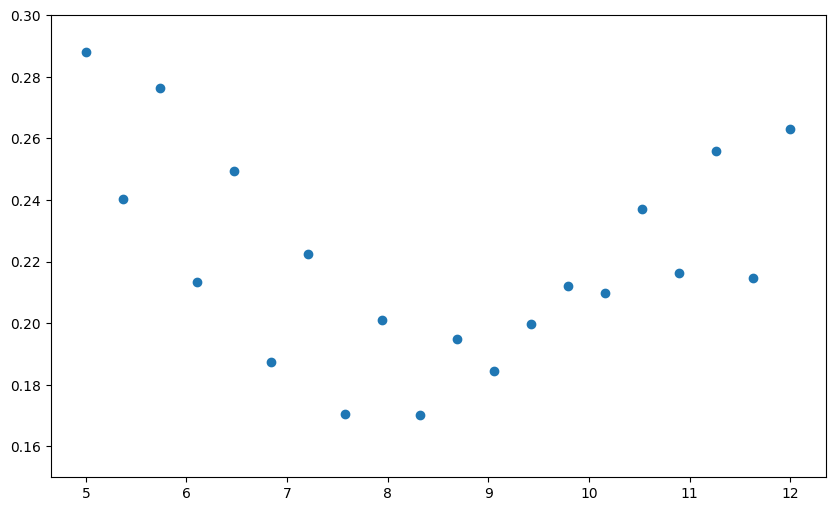

In [3]:
_, fig = plt.subplots(1, 1, figsize=(10,6))
fig.scatter(x,y)
fig.set_ylim([0.15, 0.30]);

Dane jednowymiarowe rzadko spotyka się w praktyce, ale dobrze pozwalają one na zwizualizowanie pewnych zjawisk.
Pozwalają one także na aproksymację za pomocą wielomianów; tj. model przyjmie postać:
$$f(x,\theta) = \theta_{n} \cdot x^n + \theta_{n-1} \cdot x^{n-1} + \cdots + \theta_1 \cdot x + \theta_0$$
Aby z nich skorzystać, skorzystamy z API [`numpy.polynomial`](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.polynomial.Polynomial.html#numpy.polynomial.polynomial.Polynomial).
Zacznijmy od wielomianu stopnia 2.

[ 0.19096154 -0.007625    0.07985969]


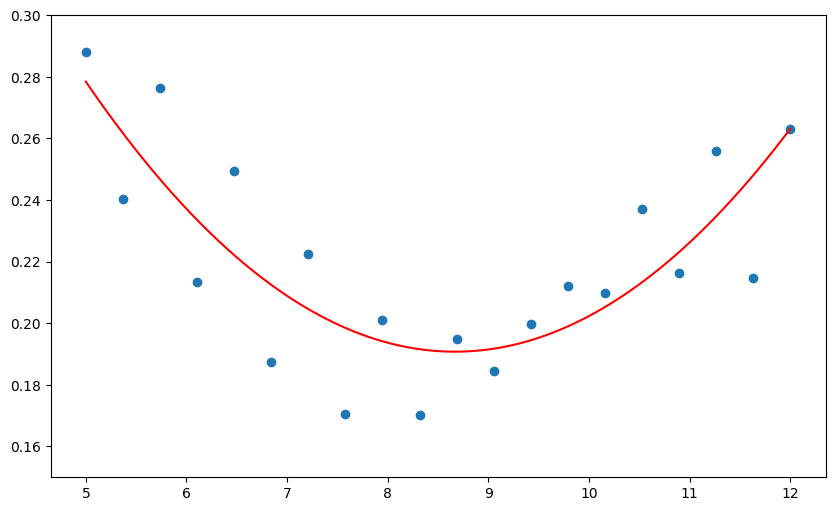

In [4]:
# dopasowanie wielomianu do danych
f = np.polynomial.Polynomial.fit(x, y, deg=2)
# rysowanie wykresu
x_plot, yhat_plot = f.linspace(n=10*N, domain=[X0, X1])
_, fig = plt.subplots(1, 1, figsize=(10,6))
fig.scatter(x, y)
fig.plot(x_plot, yhat_plot, c='r')
fig.set_ylim([0.15, 0.30]);
# sprawdzenie wartości parametrów modelu (theta)
print(f.coef)

Widać "na oko", że dopasowanie nie jest idealne: model myli się dla każdego punktu w zbiorze danych - krzywa niemal nigdy nie przechodzi przez punkty danych.
Możemy skwantyfikować tę obserwację poprzez wprowadzenie funkcji kosztu.
Dla problemów regresyjnych, jak wyżej, często używaną funkcją jest _błąd średniokwadratowy_ (_mean squared error_, MSE):
$$L_{MSE}(Y,\hat{Y}) = \frac{1}{n}\sum_{i}^{n}(y_{i}-\hat{y_i})^2$$

In [5]:
def MSE(target, prediction):
    return np.sum((target-prediction)**2) / target.size

Dla naszego zbioru danych błąd wyniesie:

In [6]:
yhat = f(x)  # ewaluacja modelu dla zadanych próbek
MSE(y, yhat)

np.float64(0.00036345757844626064)

Sprawdź, jak zmieni się zachowanie modelu, jeśli zwiększysz stopień wielomianu.
Inkrementuj go stopniowo, aż dalsza poprawa przestanie być możliwa.
Obserwuj zarówno jakościowe efekty (kształt krzywej) jak i błąd modelu.
_Co dzieje się z wartościami samych parametrów modelu?_

[ 1.77710419e-01  3.17169081e-01  1.99344418e+00 -3.25858113e+01
 -8.43732163e+01  9.84953493e+02  1.39713508e+03 -1.28844740e+04
 -1.09935068e+04  8.71981964e+04  4.64098357e+04 -3.32428978e+05
 -1.10552411e+05  7.37052482e+05  1.48070690e+05 -9.37276975e+05
 -1.03531616e+05  6.30734401e+05  2.92823512e+04 -1.73347350e+05]


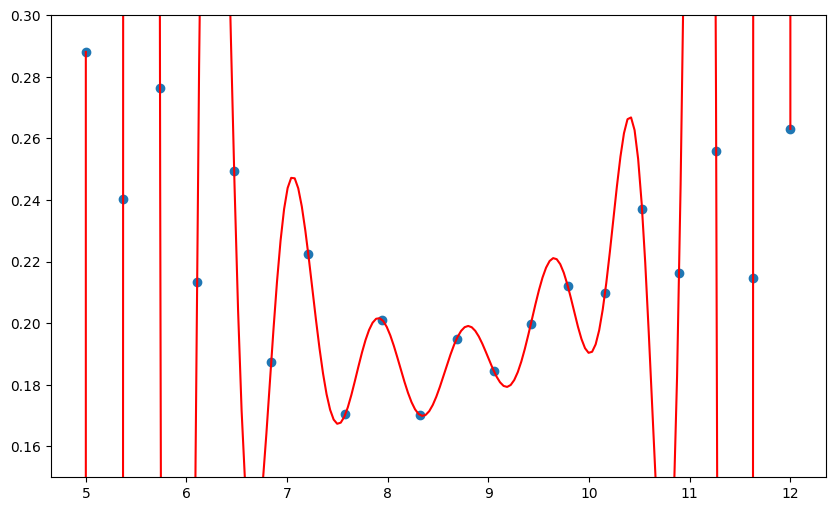

In [7]:

# dopasowanie wielomianu do danych
f = np.polynomial.Polynomial.fit(x, y, deg=19)
# rysowanie wykresu
x_plot, yhat_plot = f.linspace(n=10*N, domain=[X0, X1])
_, fig = plt.subplots(1, 1, figsize=(10,6))
fig.scatter(x, y)
fig.plot(x_plot, yhat_plot, c='r')
fig.set_ylim([0.15, 0.30]);
# sprawdzenie wartości parametrów modelu (theta)
print(f.coef)











In [8]:
yhat = f(x)  # ewaluacja modelu dla zadanych próbek
MSE(y, yhat)

np.float64(5.468191400953728e-21)

Jak widać, możliwe jest idealne (z dokładnością do reprezentacji zmiennoprzecinkowej) dopasowanie modelu do danych.
Pytanie, co ze _zdolnością predykcyjną_ tak dopasowanego modelu? Czy można ufać, że dla nowych danych będzie dobrze się sprawdzał?

Aby to sprawdzić, wykonamy eksperyment ("reakcję chemiczną") ponownie, dla nieco innych wartości "temperatury".
Następnie Ty sprawdzisz, jak predykcje modelu mają się do nowych danych.

In [9]:
# powtórny "eksperyment"
unseen_x = np.linspace(X0 + 0.185, X1 - 0.185, num=10)  # nowa dziedzina
unseen_y = data_generating_process(unseen_x)  # nowe obserwacje

MSE: 370.1174310315995



(0.15, 0.3)

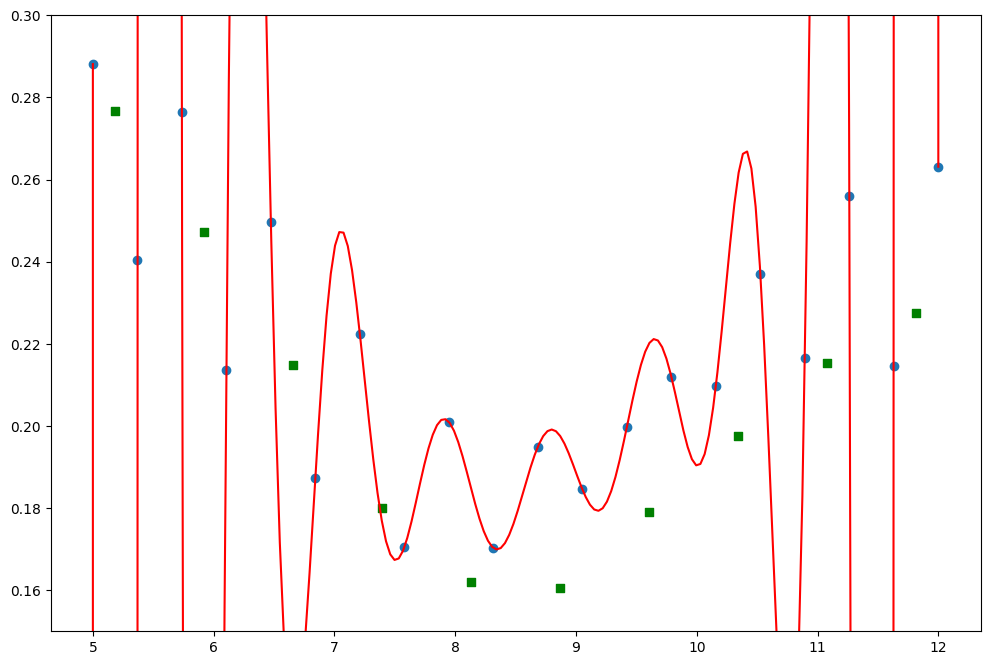

In [10]:
# TODO
unseen_yhat = f(unseen_x)
mse = MSE(unseen_y, unseen_yhat)
print(f'MSE: {mse}')
print()


# rysowanie wykresu
_, fig = plt.subplots(1, 1, figsize=(12,8))
fig.scatter(x, y)
fig.scatter(unseen_x, unseen_y, c='g', marker='s')
fig.plot(x_plot, yhat_plot, c='r')

fig.set_ylim([0.15, 0.30])

Choć powyższy przykład jest nieco zabawkowy, zjawiska, które ilustruje, są uniwersalne i mają miejsce _zawsze_ podczas pracy z modelami, w mniejszym lub większym stopniu.
Przedstawienie ich na tak prostym problemie i modelu ma natomiast tę zaletę, że zjawiska te są bardzo wyraźnie widoczne "gołym okiem", co z reguły nie ma miejsca gdy pracujemy na prawdziwych, złożonych danych i skomplikowanych modelach ML.

Uniwersalne są również wnioski, które z tego tutorialu należy wyciągnąć;
powinny one odpowiadać na conajmniej dwa najważniejsze pytania:
- Jak należy postępować z danymi, aby uniknąć (a przynajmniej w porę dostrzec) problem nadmiernego dopasowania (_overfitting_)?
- Jak należy dobierać hiperparametry modelu, aby zminimalizować ryzyko wystąpienia tego zjawiska?  
Jaki efekt uboczny może w takim podejściu wystąpić?

---

Laboratorium 3

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.model_selection import train_test_split

In [12]:
#wczytanie danych
heart = pd.read_csv('/content/Heart_disease_cleveland_new.csv')
heart

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,0,110,264,0,0,132,0,1.2,1,0,3,1
299,68,1,3,144,193,1,0,141,0,3.4,1,2,3,1
300,57,1,3,130,131,0,0,115,1,1.2,1,1,3,1
301,57,0,1,130,236,0,2,174,0,0.0,1,1,1,1


In [13]:
print("=== Typy danych ===")
heart.info()

=== Typy danych ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [14]:
print("=== Informacje statystyczne ===")
heart.describe()

=== Informacje statystyczne ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,2.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,0.600660,0.663366,1.831683,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,0.956705,0.499120
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,1.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,3.000000,1.000000


|cecha|opis|dane|
|:---:|:---:|:---:|
|Age|wiek pacjenta|-|
|Sex|płeć pacjenta|1 - mężczyzna, 0 - kobieta|
|cp|rodzaj bólu w klatce piersiowej|4 kategorie: 0-3|
|trestbps|ciśnienie spoczynkowe|w [mm/Hg]|
|chol|poziom cholesterolu|w [mg/dl]|
|fbs|czy poziom cukru we krwi przekracza 120mg/dl|1 - tak, 0-nie|
|restecg|wynik badania EKG|3 grupy: 0-2|
|thalach|maksymalne osiągnięte tętno|-|
|exang|czy wysiłek fizyczny wywował ból dławicowy|1 - tak, 0 - nie|
|oldpeak|obniżenie odcinka ST wywołane wysiłkiem|-|
|slope|kształt nachylenia odcinka ST w szczycie wysiłku|3 rodzaje: 0-2|
|ca|liczba głównych naczyń krwionośnych|od 0 do 3|
|thal|rodzaj przepływu krwi w sercu związany z występowaniem lub brakiem talasemii|4 rodzaje: 0-3|
|target|czy chory|1 - chory, 0 - zdrowy|

<Axes: xlabel='target', ylabel='count'>

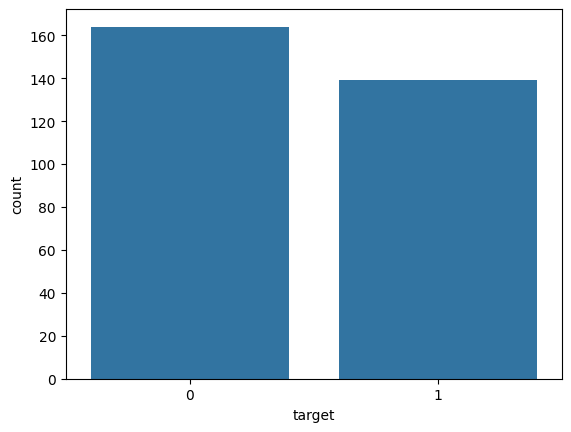

In [15]:
# rozkłady w danych
sns.countplot(
    data=heart,
    x='target'
)

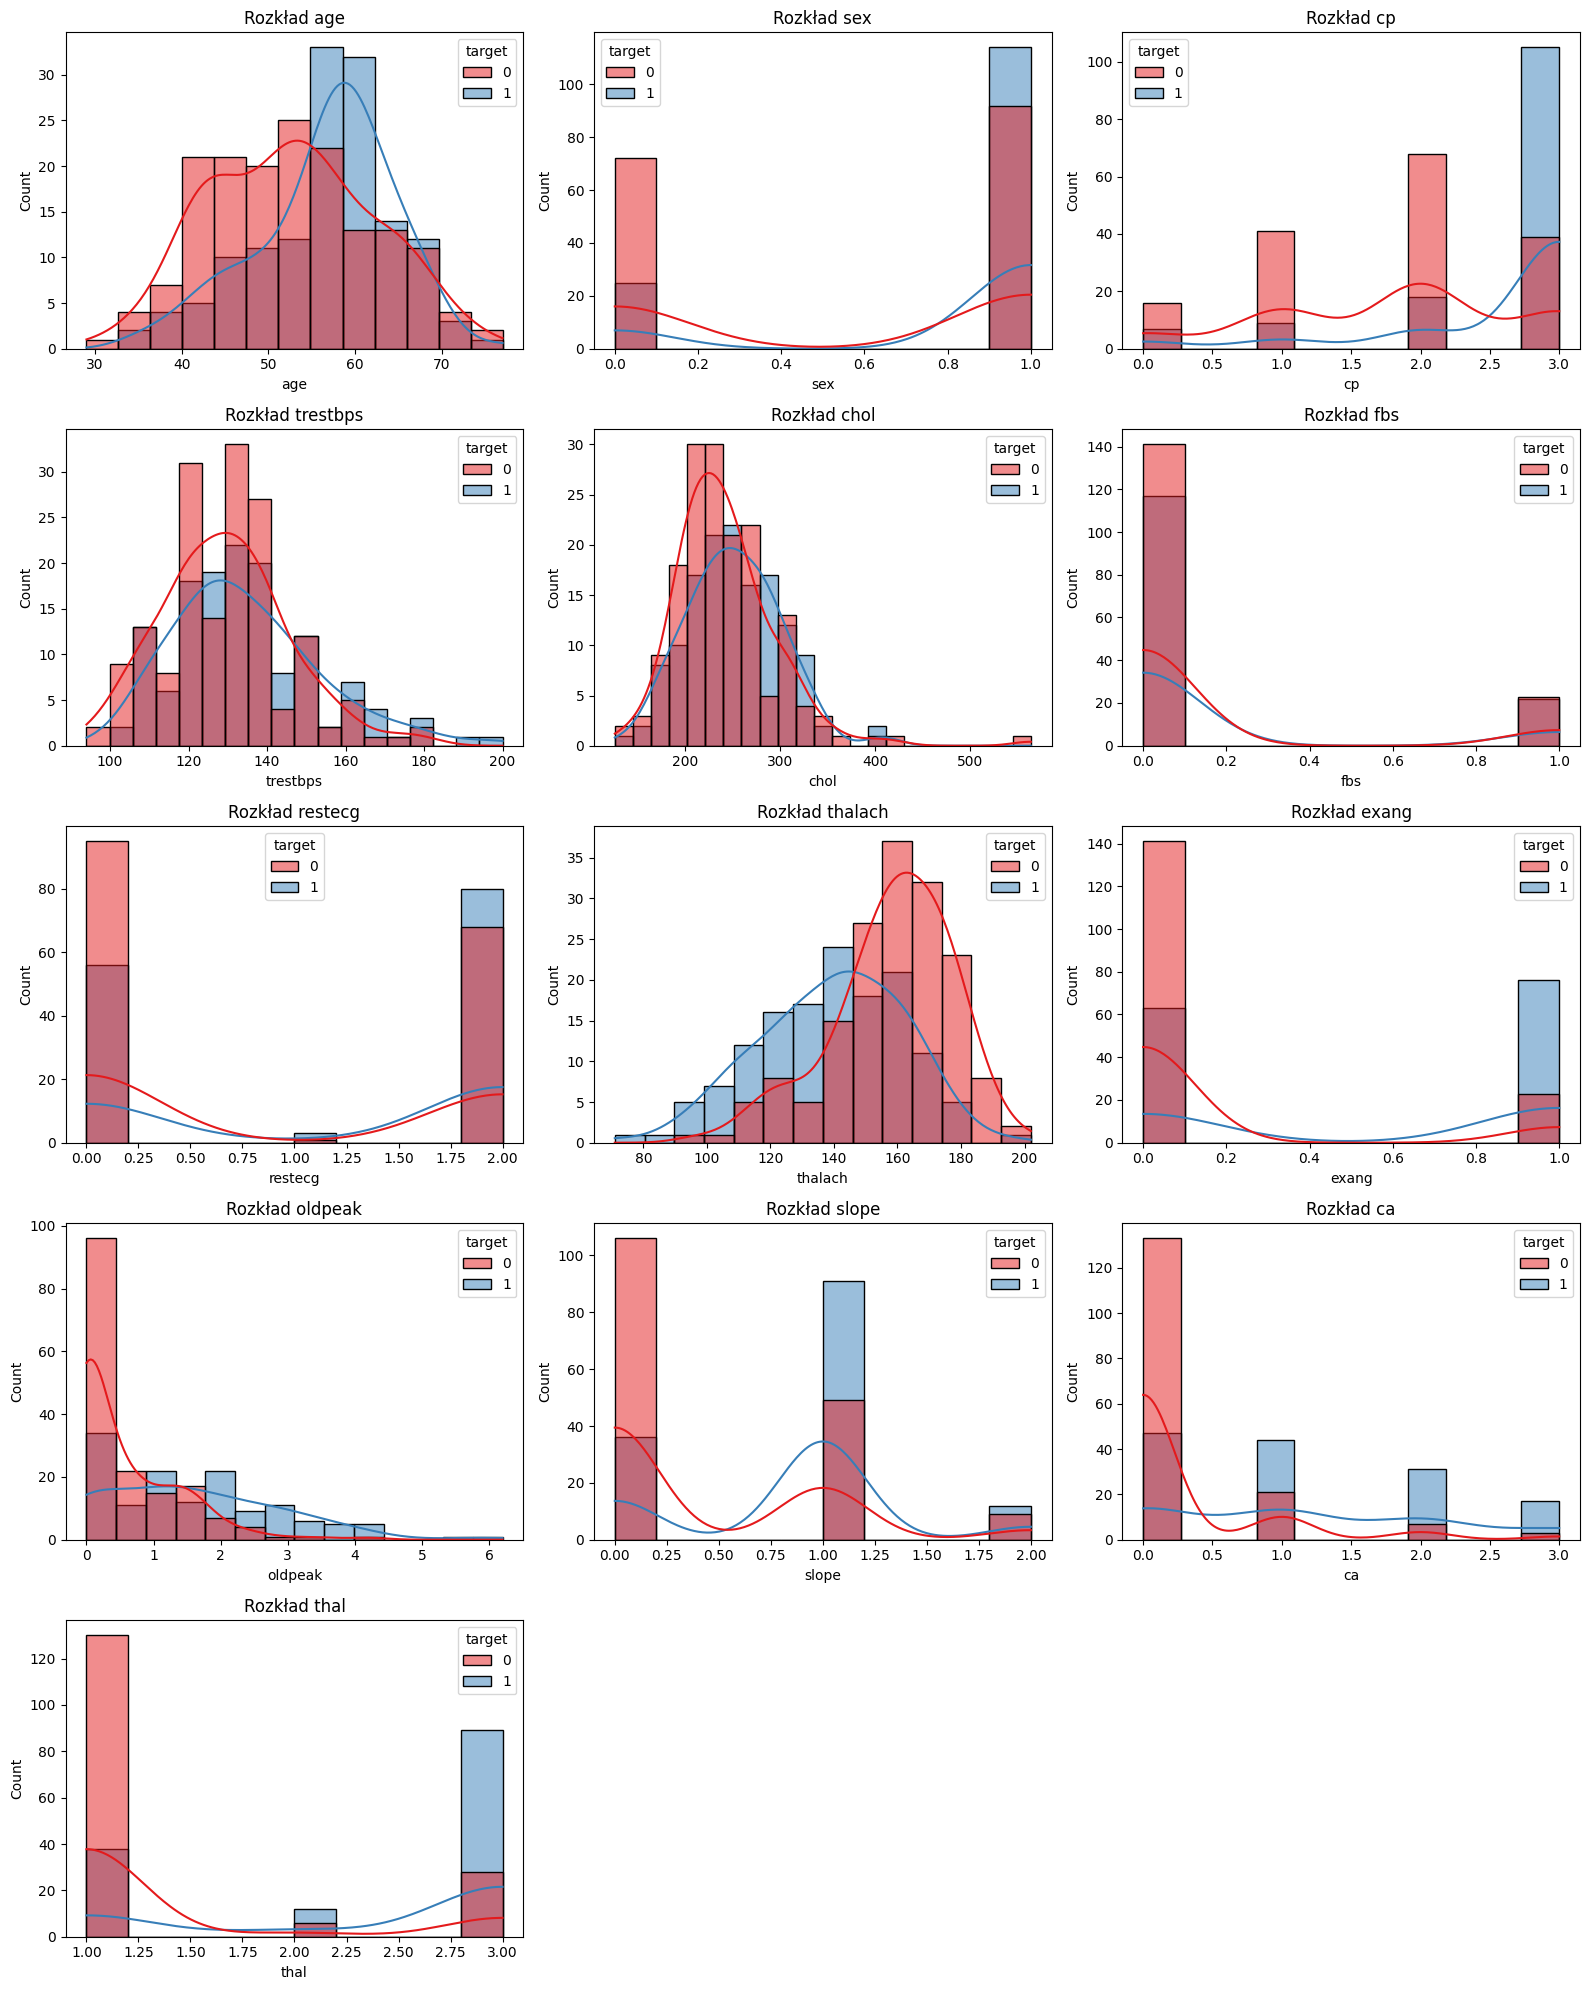

In [16]:
features = heart.columns.drop('target')
cols = 3
rows = math.ceil(len(features)/cols)
fig, axes = plt.subplots(rows, cols, figsize=(16, rows*4))
axes = axes.flatten()

for i, col in enumerate(features):
  sns.histplot(
      data=heart,
      x=col,
      hue='target',
      kde=True,
      ax=axes[i],
      palette='Set1'
  )
  axes[i].set_title(f"Rozkład {col}")

for j in range(i+1, len(axes)):
  fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Na podstawie wykresów rozkładów widać, że najmniej użyteczne będą cechy: `trestbps, chol, fbs`. Czy na tym etapie można je odrzucić?

In [17]:
# podział na zbiór treningowy i testowy
X = heart.drop('target', axis=1)
y = heart['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Dane podzieliłem w proporcji 80/20.

Za pomocą `stratify=y` zapewniłem, że proporcja osób chorych do zdrowych będzie w miarę podobna w zbiorze testowym i w treningowym.



---



ZADANIE 2

Stwórz i wytrenuj instancję modelu regresji logistycznej korzystając z modułu LogisticRegression().

In [18]:
from sklearn.linear_model import LogisticRegression

In [19]:
log_reg = LogisticRegression(max_iter=3000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

print("Model regresji logistycznej został stworzony i wytrenowany.")

Model regresji logistycznej został stworzony i wytrenowany.


Za pierwszym razem ustawiłem `max_iter = 1000`, jednak otrzymałem informację zwrotną o konieczności podniesienia tej wartości lub znormalizowaniu danych.



---



ZADANIE 3

Oceń działanie modelu - wykorzystaj metryki klasyfikacji, w tym macierz pomyłek
i krzywą ROC. Wybierz dwie metryki klasyfikacji (np. precyzję i czułość) i zinterpretuj je w kontekście zadania.

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, precision_score, recall_score

In [21]:
print("=== Raport klasyfikacji ===")
print(classification_report(y_test, y_pred))

=== Raport klasyfikacji ===
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



In [22]:
# precyzja
precision = precision_score(y_test, y_pred)
print(f"Precyzja: {precision}")

Precyzja: 0.8125


In [23]:
# czułość
recall = recall_score(y_test, y_pred)
print(f"Czułość: {recall}")

Czułość: 0.9285714285714286


Precyzja ($precision = \frac{TP}{TP+FP}$) informuje, że jeśli model postawił diagnozę "chory", to w 81% ma rację. Pozostałe 19% to tzw. fałszywe alarmy, czyli osoby zdrowe, które model błędnie uznał za chore.

Czułość ($recall = \frac{TP}{TP+FN}$) mówi, że model prawidłowo wykrył 93% z wszystkich faktycznie chorych osób w zbiorze. 7% chorych osób zostało błędnie uznanych za zdrowe.

Precyzję wybieramy, kiedy chcemy zredukować fałszywe alarmy (np. filtr antyspamowy), a czułość, gdy chcemy ograniczyć przeoczenie zdarzenia (np. wykrycie awarii lub choroby). Dlatego w naszym przypadku najważniejsza będzie czułość.

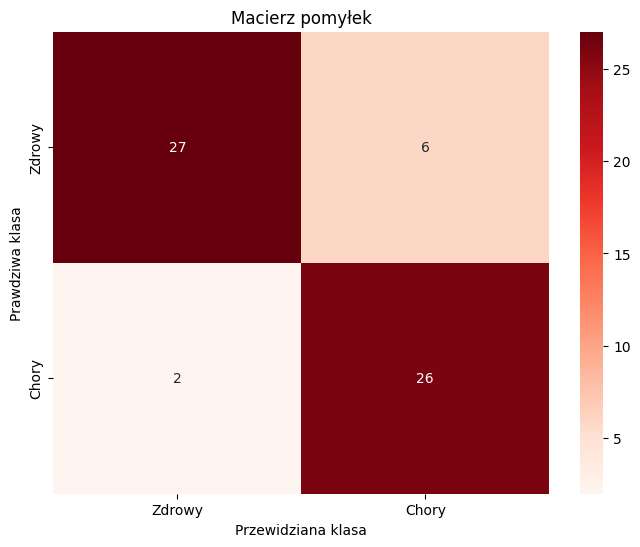

In [24]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Zdrowy', 'Chory'],
            yticklabels=['Zdrowy', 'Chory'])
plt.xlabel('Przewidziana klasa')
plt.ylabel('Prawdziwa klasa')
plt.title('Macierz pomyłek')
plt.show()

Widać, że model częściej zgłasza fałszywy alarm niż przeocza chorobę.

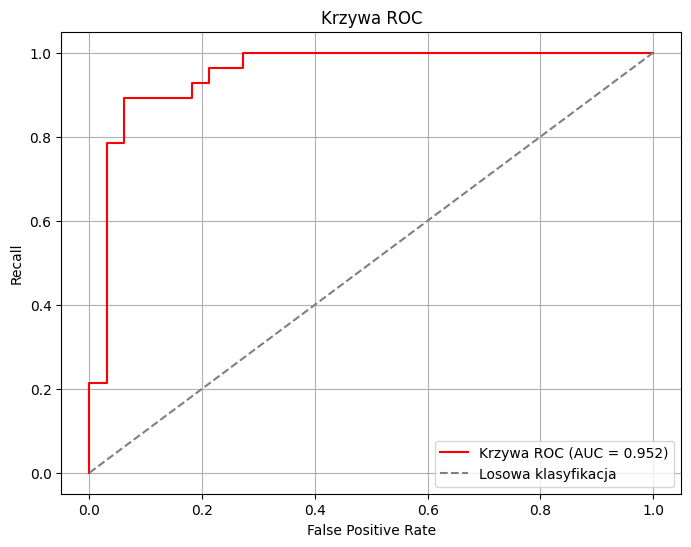

In [25]:
# krzywa ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='red', label=f"Krzywa ROC (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label="Losowa klasyfikacja")
plt.xlabel('False Positive Rate')
plt.ylabel('Recall')
plt.title("Krzywa ROC")
plt.legend()
plt.grid(True)
plt.show()

Krzywa ROC to graficzne przedstawienie tego, jak dobrze model radzi sobie z rozróżnianiem dwóch klas przy różnych progach decyzyjnych. Im mocniej jest przyciągnięta w stronę lewego górnego rogy, tym lepiej klasyfikator oddziela osoby chore od zdrowych.

W naszym przypadku krzywa ma bardzo wysoki wskaźnik pola pod krzywą (ponad 0.95). Jej kształt udowadnia bardzo dobrą skuteczność w rozróżnianiu chorych od zdrowych. W skrócie model potrafi osiągnąć bardzo wysoką czujność przy utrzymaniu bardzo niskiego odsetka fałszywych alarmów.



---



ZADANIE 4

Sprawdź, jak na działanie modelu wpływają standaryzacja i normalizacja danych.

In [26]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [27]:
# standaryzacja
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg_scaled = LogisticRegression(random_state=42)
log_reg_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = log_reg_scaled.predict(X_test_scaled)

print("=== Raport klasyfikacji po standaryzacji ===")
print(classification_report(y_test, y_pred_scaled))

precision_scaled = precision_score(y_test, y_pred_scaled)
recall_scaled = recall_score(y_test, y_pred_scaled)

print(f"Precyzja przed standaryzacją: {precision}")
print(f"Precyzja po standaryzacji: {precision_scaled}")
print(f"Czułość przed standaryzacją: {recall}")
print(f"Czułość po standaryzacji: {recall_scaled}")

=== Raport klasyfikacji po standaryzacji ===
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61

Precyzja przed standaryzacją: 0.8125
Precyzja po standaryzacji: 0.8125
Czułość przed standaryzacją: 0.9285714285714286
Czułość po standaryzacji: 0.9285714285714286


Ciekawe, bo standaryzacja nie wpłynęła ostatecznie na polepszenie wyników. Jednak w przypadku standaryzacji takie wyniki udało się osiągniąć w zdecydowanie mniejszej liczbie iteracji (domyślnie `max_iter=100`) bez zgłaszanie błędów, jak to było w przypadku ręcznie zwiększanego iteratora.

In [28]:
# normalizacja
normalizer = MinMaxScaler()

X_train_norm = normalizer.fit_transform(X_train)
X_test_norm = normalizer.transform(X_test)

log_reg_norm = LogisticRegression(random_state=42)
log_reg_norm.fit(X_train_norm, y_train)

y_pred_norm = log_reg_norm.predict(X_test_norm)

print("=== Raport klasyfikacji po normalizacji ===")
print(classification_report(y_test, y_pred_norm))

precision_norm = precision_score(y_test, y_pred_norm)
recall_norm = recall_score(y_test, y_pred_norm)

print(f"Precyzja przed normalizacją: {precision}")
print(f"Precyzja po normalizacji: {precision_norm}")
print(f"Czułość przed normalizacją: {recall}")
print(f"Czułość po normalizacji: {recall_norm}")

=== Raport klasyfikacji po normalizacji ===
              precision    recall  f1-score   support

           0       0.90      0.82      0.86        33
           1       0.81      0.89      0.85        28

    accuracy                           0.85        61
   macro avg       0.85      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61

Precyzja przed normalizacją: 0.8125
Precyzja po normalizacji: 0.8064516129032258
Czułość przed normalizacją: 0.9285714285714286
Czułość po normalizacji: 0.8928571428571429


Normalizacji również udało się osiągnąć wyniki przy limicie iteracji równym 100, jednak w jej przypadku wyniki nieco się pogorszyły. Być może jest to spowodowane wrażliwością na outliery w danych.



---



ZADANIE 5

Sprawdź, jak na działanie modelu wpływają jego parametry - siła regularyzacji czy
l1_ratio. Przeanalizuj, jak zmieniają się metryki dla różnych wartości hiperparametrów. Czy dla różnych zestawów hiperparametrów jest potrzebna inna liczba
iteracji? Uwaga - nie wykonuj tego podpunktu z użyciem GridSearch.

In [29]:
# siła regularyzacji
C_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
data = []

print("=== Badanie wpływu siły regularyzacji ===")
for C in C_values:
  log_reg_c = LogisticRegression(C=C, random_state=42)
  log_reg_c.fit(X_train_scaled, y_train)

  y_pred_c = log_reg_c.predict(X_test_scaled)

  precision_c = precision_score(y_test, y_pred_c)
  recall_c = recall_score(y_test, y_pred_c)
  iterations = log_reg_c.n_iter_[0]
  result = {'C':C, 'Precyzja':precision_c, 'Czułość':recall_c, 'Liczba iteracji':iterations}
  data.append(result)
  print(f"C={C} | Precyzja: {precision_c:.3f} | Czułość: {recall_c:.3f} | Liczba iteracji: {iterations}")

=== Badanie wpływu siły regularyzacji ===
C=0.001 | Precyzja: 0.955 | Czułość: 0.750 | Liczba iteracji: 7
C=0.01 | Precyzja: 0.862 | Czułość: 0.893 | Liczba iteracji: 8
C=0.1 | Precyzja: 0.812 | Czułość: 0.929 | Liczba iteracji: 7
C=1.0 | Precyzja: 0.812 | Czułość: 0.929 | Liczba iteracji: 9
C=10.0 | Precyzja: 0.812 | Czułość: 0.929 | Liczba iteracji: 11
C=100.0 | Precyzja: 0.812 | Czułość: 0.929 | Liczba iteracji: 11


,C,Precyzja,Czułość,Liczba iteracji
0,0.001,0.954545,0.750000,7
1,0.010,0.862069,0.892857,8
2,0.100,0.812500,0.928571,7
3,1.000,0.812500,0.928571,9
4,10.000,0.812500,0.928571,11
5,100.000,0.812500,0.928571,11


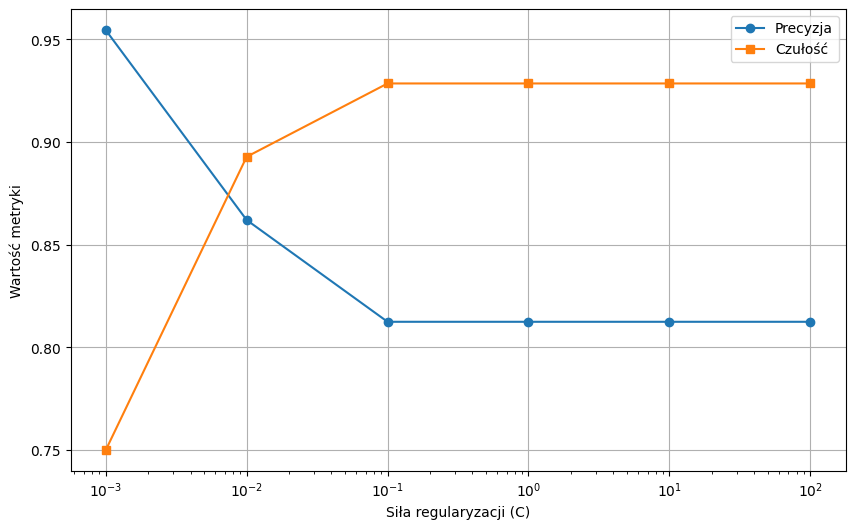

In [30]:
df_results = pd.DataFrame(data)
display(df_results)

plt.figure(figsize=(10, 6))
plt.plot(df_results['C'], df_results['Precyzja'], marker='o', label='Precyzja')
plt.plot(df_results['C'], df_results['Czułość'], marker='s', label='Czułość')
plt.xscale('log')
plt.xlabel('Siła regularyzacji (C)')
plt.ylabel('Wartość metryki')
plt.legend()
plt.grid(True)
plt.show()

Bardzo niskie wartości parametru C poskutkowały znacznym wzrostem precyzji, kosztem dużego spadku czułości (model jest ostrożny, przez co rzadko się myli, ale często przeocza chorych).

W miarę zwiększania wartości model zaczyna priorytetyzować wykrycie wszystkich chorych kosztem częstszych fałszywych alarmów. Dla $C\geq 0.1$ wyniki się stabilizują i są podobne do wcześniej osiąganych.

Im większa wartość C, tym więcej model potrzebuje iteracji do zbiegnięcia.

Badanie parametru C, to szukanie złotego środka między modelem zbyt ostrożnym, który boi się popełniać błędy, a model który nauczył się wzorców na pamięć. Dlatego zatrzymanie C w przedziale (0.1, 1.0) pozwala zachować najlepszą skuteczność, przy utrzymaniu w miarę silnej regularyzacji.

In [31]:
# parametr l1_ratio
l1_rations = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
data = []

print("=== Badanie wpływu parametru l1_ratio ===")
for l1 in l1_rations:
  log_reg_l1 = LogisticRegression(penalty='elasticnet', solver='saga' ,l1_ratio=l1, random_state=42)
  log_reg_l1.fit(X_train_scaled, y_train)

  y_pred_l1 = log_reg_l1.predict(X_test_scaled)

  precision_l1 = precision_score(y_test, y_pred_l1)
  recall_l1 = recall_score(y_test, y_pred_l1)
  iterations = log_reg_l1.n_iter_[0]

  result = {'l1_ratio':l1, 'Precyzja':precision_l1, 'Czułość':recall_l1, 'Liczba iteracji':iterations}
  data.append(result)

  print(f"l1_ratio={l1} | Precyzja: {precision_l1:.3f} | Czułość: {recall_l1:.3f} | Liczba iteracji: {iterations}")

=== Badanie wpływu parametru l1_ratio ===
l1_ratio=0.0 | Precyzja: 0.812 | Czułość: 0.929 | Liczba iteracji: 21
l1_ratio=0.2 | Precyzja: 0.812 | Czułość: 0.929 | Liczba iteracji: 21
l1_ratio=0.4 | Precyzja: 0.812 | Czułość: 0.929 | Liczba iteracji: 21
l1_ratio=0.6 | Precyzja: 0.812 | Czułość: 0.929 | Liczba iteracji: 21
l1_ratio=0.8 | Precyzja: 0.812 | Czułość: 0.929 | Liczba iteracji: 21
l1_ratio=1.0 | Precyzja: 0.812 | Czułość: 0.929 | Liczba iteracji: 21


In [32]:
C_values = [0.01, 0.1, 1.0]
li_rations = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
data = []

print("=== Badanie wpływu obu parametrów ===")
for C in C_values:
  for l1 in li_rations:
    log_reg_grid = LogisticRegression(C=C, penalty='elasticnet', solver='saga' ,l1_ratio=l1, random_state=42)
    log_reg_grid.fit(X_train_scaled, y_train)

    y_pred_grid = log_reg_grid.predict(X_test_scaled)

    precision_grid = precision_score(y_test, y_pred_grid, zero_division=0)
    recall_grid = recall_score(y_test, y_pred_grid)

    result = {
        'C': C,
        'l1_ratio': l1,
        'Precyzja': precision_grid,
        'Czułość': recall_grid
    }
    data.append(result)
    print(f"C={C} | l1_ratio={l1} | Precyzja: {precision_grid:.3f} | Czułość: {recall_grid:.3f}")

=== Badanie wpływu obu parametrów ===
C=0.01 | l1_ratio=0.0 | Precyzja: 0.862 | Czułość: 0.893
C=0.01 | l1_ratio=0.2 | Precyzja: 0.926 | Czułość: 0.893
C=0.01 | l1_ratio=0.4 | Precyzja: 0.905 | Czułość: 0.679
C=0.01 | l1_ratio=0.6 | Precyzja: 0.000 | Czułość: 0.000
C=0.01 | l1_ratio=0.8 | Precyzja: 0.000 | Czułość: 0.000
C=0.01 | l1_ratio=1.0 | Precyzja: 0.000 | Czułość: 0.000
C=0.1 | l1_ratio=0.0 | Precyzja: 0.812 | Czułość: 0.929
C=0.1 | l1_ratio=0.2 | Precyzja: 0.806 | Czułość: 0.893
C=0.1 | l1_ratio=0.4 | Precyzja: 0.806 | Czułość: 0.893
C=0.1 | l1_ratio=0.6 | Precyzja: 0.828 | Czułość: 0.857
C=0.1 | l1_ratio=0.8 | Precyzja: 0.828 | Czułość: 0.857
C=0.1 | l1_ratio=1.0 | Precyzja: 0.828 | Czułość: 0.857
C=1.0 | l1_ratio=0.0 | Precyzja: 0.812 | Czułość: 0.929
C=1.0 | l1_ratio=0.2 | Precyzja: 0.812 | Czułość: 0.929
C=1.0 | l1_ratio=0.4 | Precyzja: 0.812 | Czułość: 0.929
C=1.0 | l1_ratio=0.6 | Precyzja: 0.812 | Czułość: 0.929
C=1.0 | l1_ratio=0.8 | Precyzja: 0.812 | Czułość: 0.929
C=1.

,C,l1_ratio,Precyzja,Czułość
0,0.01,0.0,0.862069,0.892857
1,0.01,0.2,0.925926,0.892857
2,0.01,0.4,0.904762,0.678571
3,0.01,0.6,0.000000,0.000000
4,0.01,0.8,0.000000,0.000000
5,0.01,1.0,0.000000,0.000000
6,0.10,0.0,0.812500,0.928571
7,0.10,0.2,0.806452,0.892857
8,0.10,0.4,0.806452,0.892857
9,0.10,0.6,0.827586,0.857143


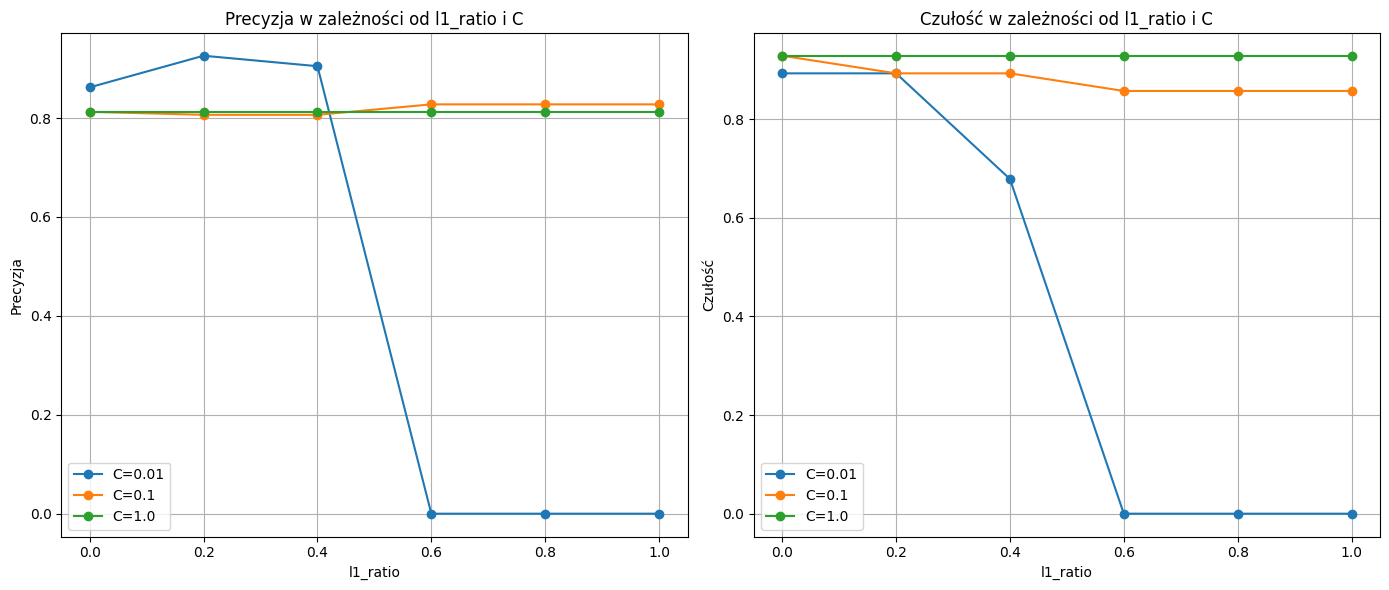

In [33]:
df_results = pd.DataFrame(data)
display(df_results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for C in C_values:
  subset = df_results[df_results['C'] == C]
  ax1.plot(subset['l1_ratio'], subset['Precyzja'], marker='o', label=f'C={C}')
  ax2.plot(subset['l1_ratio'], subset['Czułość'], marker='o', label=f'C={C}')

ax1.set_title('Precyzja w zależności od l1_ratio i C')
ax1.set_xlabel('l1_ratio')
ax1.set_ylabel('Precyzja')
ax1.legend()
ax1.grid(True)

ax2.set_title('Czułość w zależności od l1_ratio i C')
ax2.set_xlabel('l1_ratio')
ax2.set_ylabel('Czułość')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

Ponieważ dla domyślnego `C=1.0` parametr `l1_ratio` nie ma większego wpływu na końcowe wyniki, postanowiłem porównać współzależność parametrów siły regularyzacji i l1_ratio.

Jak widać na wykresach, dla `C=1.0` zmiana `l1_ratio` nie wpływa na wyniki (zielona linia biegnie niemal poziomo zarówno dla precyzji jak i dla czułości). Dla `C=0.1` wyniki są stabilne z minimalnym wzrostem precyzji i lekkim spadkiem czułości wraz ze wzrostem `l1_ratio`. Dla `C=0.01` sytuacja jest bardziej ciekawa. Dla `l1_ratio=0.2` model osiągnął najwyższą precyzję spośród pozstałych danych przy jednocześnie wysokiej czułości. Jednak w przypadku `l1_ratio >= 0.6` obie miary spadły do zera.



---



ZADANIE 6

Zbadaj zachowanie modelu przy zastosowaniu walidacji krzyżowej (cross-validation)
dla różnych rozmiarów - 2-fold, 5-fold, 10-fold. Uwzględnij nie tylko średnie wartości
metryk, ale też ich zmienność.
Zbadaj, jak zmieniają się wyniki przy użyciu stratyfikacji.

In [35]:
from sklearn.model_selection import cross_validate, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [42]:
model_cv = make_pipeline(StandardScaler(), LogisticRegression(random_state=42))
folds = [2, 5, 10]
data = []

print("=== Badanie Walidacji Krzyżowej ===")
for k in folds:
  kf = KFold(n_splits=k, shuffle=True, random_state=42)
  cv_results = cross_validate(model_cv, X, y, cv=kf,
                              scoring=['precision', 'recall'],
                              return_train_score=False)
  mean_precision = cv_results['test_precision'].mean()
  mean_recall = cv_results['test_recall'].mean()
  std_precision = cv_results['test_precision'].std()
  std_recall = cv_results['test_recall'].std()
  result = {
      'k-fold': f'{k}-fold',
      'Precyzja_średnia': mean_precision,
      'Czułość_średnia': mean_recall,
      'Precyzja_zmiana': std_precision,
      'Czułość_zmiana': std_recall
  }
  data.append(result)

  print(f"Rozmiar: {k}-fold")
  print(f"Precyzja: Średnia = {mean_precision:.3f} | Zmienność = {std_precision:.3f}")
  print(f"Czułość: Średnia = {mean_recall:.3f} | Zmienność = {std_recall:.3f}")

=== Badanie Walidacji Krzyżowej ===
Rozmiar: 2-fold
Precyzja: Średnia = 0.831 | Zmienność = 0.002
Czułość: Średnia = 0.776 | Zmienność = 0.030
Rozmiar: 5-fold
Precyzja: Średnia = 0.848 | Zmienność = 0.044
Czułość: Średnia = 0.798 | Zmienność = 0.076
Rozmiar: 10-fold
Precyzja: Średnia = 0.842 | Zmienność = 0.091
Czułość: Średnia = 0.801 | Zmienność = 0.119


,k-fold,Precyzja_średnia,Czułość_średnia,Precyzja_zmiana,Czułość_zmiana
0,2-fold,0.830952,0.775912,0.002381,0.029643
1,5-fold,0.847798,0.797660,0.044475,0.076365
2,10-fold,0.841713,0.800672,0.090798,0.119440


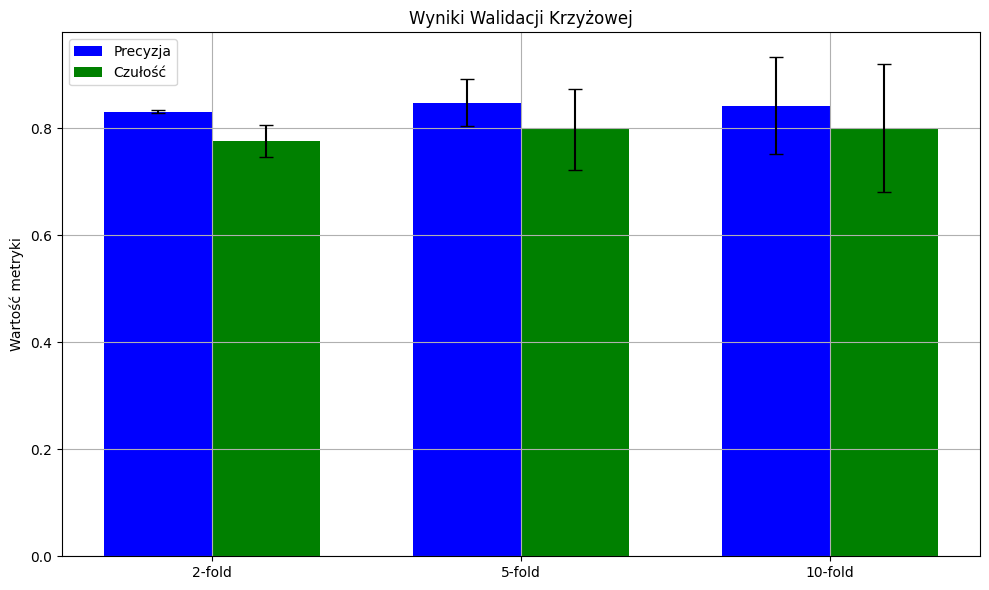

In [43]:
df_kfold = pd.DataFrame(data)
display(df_kfold)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(folds))
width = 0.35

rects1 = ax.bar(x - width/2, df_kfold['Precyzja_średnia'], width, label='Precyzja',
                yerr=df_kfold['Precyzja_zmiana'], capsize=5, color='blue')
rects2 = ax.bar(x + width/2, df_kfold['Czułość_średnia'], width, label='Czułość',
                yerr=df_kfold['Czułość_zmiana'], capsize=5, color='green')
ax.set_title('Wyniki Walidacji Krzyżowej')
ax.set_xticks(x)
ax.set_xticklabels(df_kfold['k-fold'])
ax.set_ylabel('Wartość metryki')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


Na wykresie widać stopniowy wzrost zmienności wyników wraz ze wzrostem wartości parametru k. Jest to spowodowane wielkością zbioru testowego, ponieważ w dużym zbiorze pojedyncze pomyłki nie mają aż tak dużego wpływu jak w mniejszych zbiorach.

In [44]:
data_comp = []

for k in folds:
  kf = KFold(n_splits=k, shuffle=True, random_state=42)
  cv_results = cross_validate(model_cv, X, y, cv=kf,
                              scoring=['precision', 'recall'])
  mean_precision = cv_results['test_precision'].mean()
  mean_recall = cv_results['test_recall'].mean()
  std_precision = cv_results['test_precision'].std()
  std_recall = cv_results['test_recall'].std()

  result = {
      'Metoda': 'Bez stratyfikacji',
      'k-fold': f'{k}-fold',
      'Precyzja_średnia': mean_precision,
      'Czułość_średnia': mean_recall,
      'Precyzja_zmiana': std_precision,
      'Czułość_zmiana': std_recall
  }
  data_comp.append(result)

  skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
  cv_skf = cross_validate(model_cv, X, y, cv=skf,
                        scoring=['precision', 'recall'])
  mean_precision_skf = cv_skf['test_precision'].mean()
  mean_recall_skf = cv_skf['test_recall'].mean()
  std_precision_skf = cv_skf['test_precision'].std()
  std_recall_skf = cv_skf['test_recall'].std()

  result = {
      'Metoda': 'Stratyfikacja',
      'k-fold': f'{k}-fold',
      'Precyzja_średnia': mean_precision_skf,
      'Czułość_średnia': mean_recall_skf,
      'Precyzja_zmiana': std_precision_skf,
      'Czułość_zmiana': std_recall_skf
  }
  data_comp.append(result)

,Metoda,k-fold,Precyzja_średnia,Czułość_średnia,Precyzja_zmiana,Czułość_zmiana
0,Bez stratyfikacji,2-fold,0.830952,0.775912,0.002381,0.029643
1,Stratyfikacja,2-fold,0.814068,0.783851,0.008513,0.044720
2,Bez stratyfikacji,5-fold,0.847798,0.797660,0.044475,0.076365
3,Stratyfikacja,5-fold,0.830438,0.798413,0.064315,0.066657
4,Bez stratyfikacji,10-fold,0.841713,0.800672,0.090798,0.119440
5,Stratyfikacja,10-fold,0.844053,0.791209,0.081312,0.081423


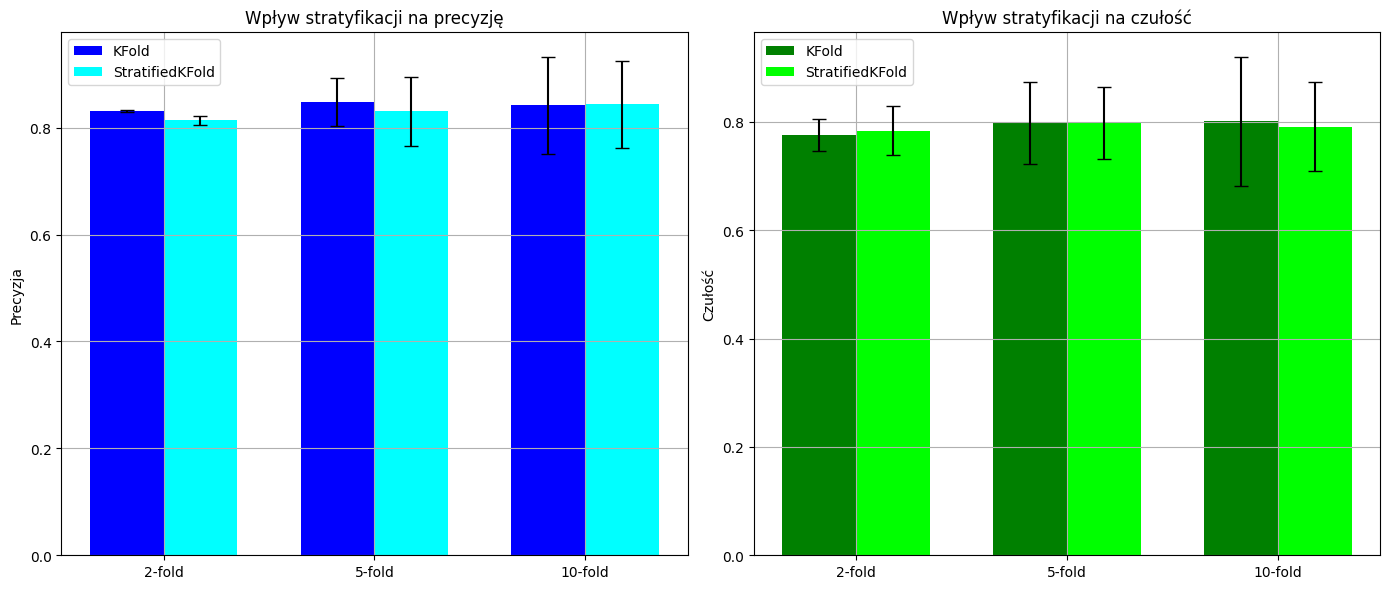

In [47]:
df_comp = pd.DataFrame(data_comp)
display(df_comp)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
x = np.arange(len(folds))
width = 0.35

df_kf = df_comp[df_comp['Metoda'] == 'Bez stratyfikacji']
df_skf = df_comp[df_comp['Metoda'] == 'Stratyfikacja']

ax1.bar(x - width/2, df_kf['Precyzja_średnia'], width, yerr=df_kf['Precyzja_zmiana'],
        label='KFold', capsize=5, color='blue')
ax1.bar(x + width/2, df_skf['Precyzja_średnia'], width, yerr=df_skf['Precyzja_zmiana'],
        label='StratifiedKFold', capsize=5, color='cyan')
ax1.set_title("Wpływ stratyfikacji na precyzję")
ax1.set_xticks(x)
ax1.set_xticklabels(df_kf['k-fold'])
ax1.set_ylabel('Precyzja')
ax1.legend()
ax1.grid(True)

ax2.bar(x - width/2, df_kf['Czułość_średnia'], width, yerr=df_kf['Czułość_zmiana'],
        label='KFold', capsize=5, color='green')
ax2.bar(x + width/2, df_skf['Czułość_średnia'], width, yerr=df_skf['Czułość_zmiana'],
        label='StratifiedKFold', capsize=5, color='lime')
ax2.set_title("Wpływ stratyfikacji na czułość")
ax2.set_xticks(x)
ax2.set_xticklabels(df_kf['k-fold'])
ax2.set_ylabel('Czułość')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

Wraz ze wzrostem liczby podziałów z 2 do 10-fold widać znaczny wzrost zmienności wyników, co wynika z faktu, że przy 10 podziałach zbiór testowy jest bardzo mały więc każda pojedyncza pomyłka ma ogromny wpływ na ostateczny wynik.

Zastosowanie stratyfikacji nie zmienia zbytnio średniej wartości metryk, jednak pozytywnie wpływa na ich stabilność, co widać na przykładzie długości czarnych wąsów (odchylenia standardowego), któro zazwyczaj jest mniejsze w przypadku jaśniejszych słupków.